# 1. Problem Statement & Business Context

In Singapore's HDB resale market, the buyer and seller must agree on a price before the official HDB valuation is released, so both sides negotiate without knowing what the flat is objectively worth. This hurts both parties: if the agreed price ends up above the valuation, the buyer pays the difference in cash(cash-over-valuation), while sellers risk overpricing and having the flat sit unsold, or underpricing and losing tens of thousands of dollars. This project builds a model that predicts a flat's resale price from its attributes (town, flat type, floor area, storey range, remaining lease) to give both sides an objective starting point. Since the target, resale_price, is a continuous dollar value and not a category, this is a regression problem.

## 2. Data Loading & Initial Inspection

In [1]:
import pandas as pd
df = pd.read_csv("data/resale-flat-prices-2017-onwards.csv")
print(df.shape)
import matplotlib.pyplot as plt
import seaborn as sns

(235247, 11)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235247 entries, 0 to 235246
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                235247 non-null  str    
 1   town                 235247 non-null  str    
 2   flat_type            235247 non-null  str    
 3   block                235247 non-null  str    
 4   street_name          235247 non-null  str    
 5   storey_range         235247 non-null  str    
 6   floor_area_sqm       235247 non-null  float64
 7   flat_model           235247 non-null  str    
 8   lease_commence_date  235247 non-null  int64  
 9   remaining_lease      235247 non-null  str    
 10  resale_price         235247 non-null  float64
dtypes: float64(2), int64(1), str(8)
memory usage: 19.7 MB


In [3]:
df.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,235247.000000,235247.000000,2.352470e+05
mean,96.688704,1996.565376,5.320577e+05
std,24.016118,14.367138,1.907679e+05
min,31.000000,1966.000000,1.400000e+05
25%,81.000000,1985.000000,3.900000e+05
50%,93.000000,1997.000000,5.000000e+05
75%,112.000000,2012.000000,6.400000e+05
max,366.700000,2022.000000,1.728000e+06


In [4]:
print("Duplicate rows:", df.duplicated().sum())
print(df.isnull().sum())

Duplicate rows: 316
month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64


In [5]:
print(df['month'].min(), "to", df['month'].max())
print(df['town'].nunique(), "towns")
print(df['flat_model'].nunique(), "flat models")
print(df['flat_type'].value_counts())
print(df['storey_range'].unique())
df['remaining_lease'].head(10)

2017-01 to 2026-07
26 towns
21 flat models
flat_type
4 ROOM              99899
5 ROOM              57542
3 ROOM              55997
EXECUTIVE           16733
2 ROOM               4902
1 ROOM                 87
MULTI-GENERATION       87
Name: count, dtype: int64
<StringArray>
['10 TO 12', '01 TO 03', '04 TO 06', '07 TO 09', '13 TO 15', '19 TO 21',
 '22 TO 24', '16 TO 18', '34 TO 36', '28 TO 30', '37 TO 39', '49 TO 51',
 '25 TO 27', '40 TO 42', '31 TO 33', '46 TO 48', '43 TO 45']
Length: 17, dtype: str


0    61 years 04 months
1    60 years 07 months
2    62 years 05 months
3     62 years 01 month
4    62 years 05 months
5              63 years
6    61 years 06 months
7    58 years 04 months
8    61 years 06 months
9    61 years 04 months
Name: remaining_lease, dtype: str

## 3. Data Cleaning & Preprocessing

The dataset spans from january 2017 to july 2026. HDB resale prices have shifted alot over this period, especially the post 2020 surge, so training on decade-old prices would change valuations for today's market. I filter to transactions from Jan 2024 onwards,recent enough to reflect current market conditions, while still keeping a large sample.

In [6]:
print("Before filtering:", df.shape)
df = df[df['month'] >= '2024-01'].copy()
print("After filtering to Jan 2024 onwards:", df.shape)

Before filtering: (235247, 11)
After filtering to Jan 2024 onwards: (66097, 11)


The full dataset contains 316 exact duplicated rows. There is no unit number column so i could not tell whether these are errors or just identical transactions, so i dropped them. if identical rows appear in the training or test sets, the test score becomes artificially inflated which makes test score look better than it accually is. Although losed some data, this is still a small cost for a trustworthy evaluation.After filtering to Jan 2024 onwards,35 duplicate rows remained and were dropped,leaving 66062 rows,all 316 were in the older data. I keep this check in as verification that the working dataset is clean.

In [7]:
before = len(df)
df = df.drop_duplicates()
print("Dropped", before - len(df), "duplicates. New shape:", df.shape)

Dropped 35 duplicates. New shape: (66062, 11)


remaining_lease ("61 years 04 months") and storey_range ("10 TO 12") are stored as text, which a model cannot use. I converted the remaining lease into decimal number of years, and storey range into the midpoint of its range (e.g:"10 TO 12"->11). I use midpoints rather than treating each band as a category because storey height is oridinal,higher floors generally sell for more,and the midpoint keeps that ordering.

In [ ]:
def lease_to_years(text):
    parts = text.split()  # "61 years 04 months" -> ["61","years","04","months"]
    years = int(parts[0])
    if len(parts) > 2:  # handles"63 years" which has no months part
        months = int(parts[2])
    else:
        months = 0
    return round(years + months / 12, 2)


def storey_to_mid(text):
    low, high = text.split(" TO ")  # "10 TO 12" -> "10", "12"
    return (int(low) + int(high)) / 2


df["remaining_lease_years"] = df["remaining_lease"].apply(lease_to_years)
df["storey_mid"] = df["storey_range"].apply(storey_to_mid)
print(df.shape)

(66062, 13)


In [9]:
df[['remaining_lease', 'remaining_lease_years', 'storey_range', 'storey_mid']].head(10)

,remaining_lease,remaining_lease_years,storey_range,storey_mid
169150,53 years 06 months,53.50,07 TO 09,8.0
169151,55 years 07 months,55.58,04 TO 06,5.0
169152,54 years 01 month,54.08,01 TO 03,2.0
169153,55 years 02 months,55.17,04 TO 06,5.0
169154,51 years 04 months,51.33,04 TO 06,5.0
169155,53 years 01 month,53.08,04 TO 06,5.0
169156,55 years 01 month,55.08,01 TO 03,2.0
169157,54 years 05 months,54.42,04 TO 06,5.0
169158,55 years 02 months,55.17,01 TO 03,2.0
169159,54 years 01 month,54.08,01 TO 03,2.0


In [10]:
df[['remaining_lease_years', 'storey_mid']].describe()

,remaining_lease_years,storey_mid
count,66062.000000,66062.000000
mean,72.702885,8.826496
std,15.294508,5.968285
min,39.580000,2.000000
25%,59.580000,5.000000
50%,72.250000,8.000000
75%,89.000000,11.000000
max,95.420000,50.000000


## 4. Exploratory Data Analysis & Interpretation

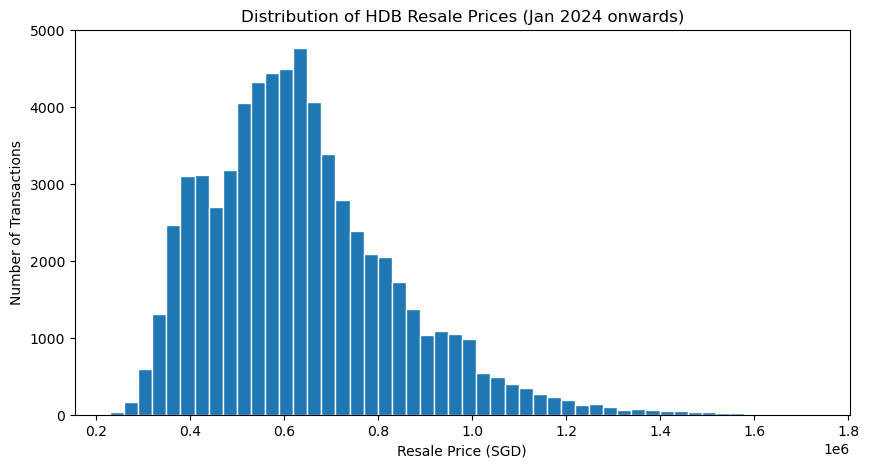

In [11]:
plt.figure(figsize=(10,5))
plt.hist(df['resale_price'], bins=50, edgecolor='white',)
plt.title('Distribution of HDB Resale Prices (Jan 2024 onwards)')
plt.xlabel('Resale Price (SGD)')
plt.ylabel('Number of Transactions')
plt.show()

In [12]:
df['resale_price'].agg(['mean', 'median'])

mean      637198.773593
median    611000.000000
Name: resale_price, dtype: float64

The graoh shows that the prices are right-skewed, which means most transactions fall between roughly $400k and $700k, with a long tail stretching past $1.5m. This matches the earlier finding that the mean ($637k) sits above the median ($611k). For the business, the wide spread confirms there is no single "market price" ,value depends heavily on the flat's feature. For modelling, the skew means errors on rare expensive flats could cause large errors, so I will keep this in mind when choosing the evaluation metric.

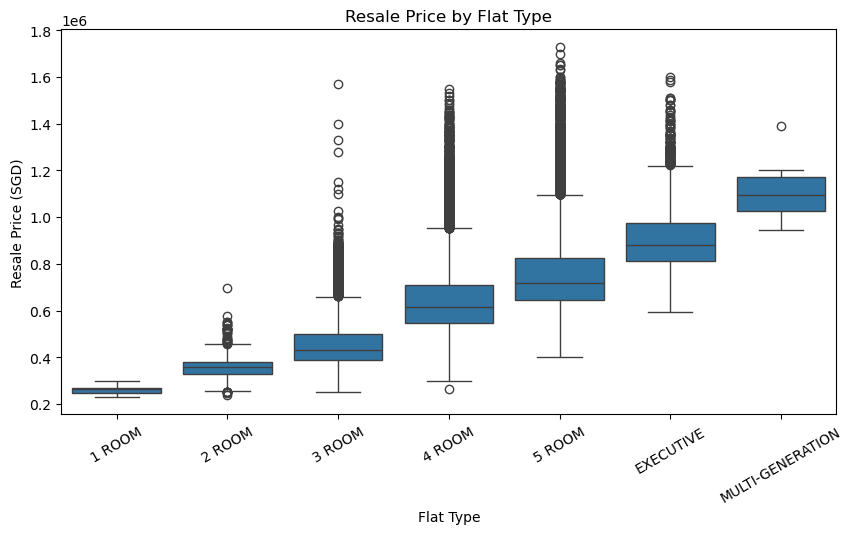

In [13]:
plt.figure(figsize=(10,5))
order = ['1 ROOM','2 ROOM','3 ROOM','4 ROOM','5 ROOM','EXECUTIVE','MULTI-GENERATION']
sns.boxplot(x='flat_type', y='resale_price', data=df, order=order)
plt.title('Resale Price by Flat Type')
plt.xlabel('Flat Type')
plt.ylabel('Resale Price (SGD)')
plt.xticks(rotation=30)
plt.show()

the median price climbs steadily as the flat size increase, from roughly $250k for 1-room flats to about $650k for 4-room, $750k for 5-room, and over $1m for multi-generation. The categories overlap quite abit, many 4-room flats sell for more than 5-room flats, and the most expensive 3-room flats(the outliers of 3-room) exceed the price of a executive flat. For the business, this shows flat size sets a baseline but does not determine the price of the flat.the overlaping of prices can be explained by other factors such as location, storey, and remaining lease. For modelling, flat_type is a strong predictor to predict price, but it cannot price a flat on its own,so it needs a multi-feature model. I also note 1-room and multi-generation flats are rare, so the model will have lesser example of this 2 flat type.

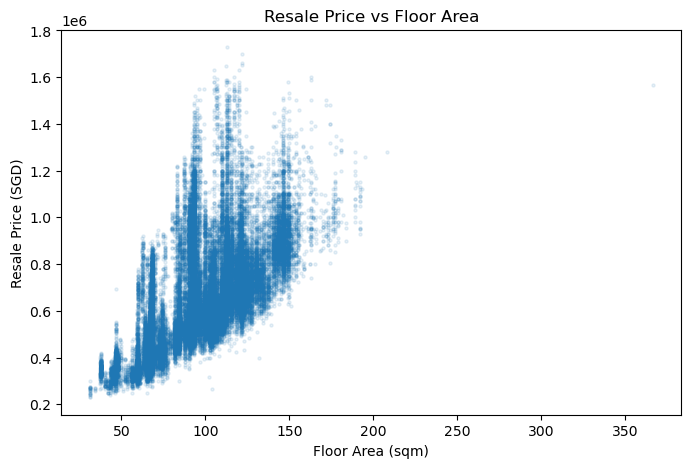

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(df['floor_area_sqm'], df['resale_price'], alpha=0.1, s=5)
plt.title('Resale Price vs Floor Area')
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Resale Price (SGD)')
plt.show()

There is a positive relationship between floor area(sqm) and resale price(SGD), where larger flats  sell for higher price. The prive spread of any size is very huge, flats around 95–100 sqm cost from roughly $400k to over $1.5m, a 3–4 times range for the same floor area. The vertical pattern appear because HDB flats are in standard sizes, so many share same areas.A simple price per sqm calculation cannot value the cost of the flat because same-sized flats differ massively from location, storey, and lease. For modelling, floor area is an important feature but must be combined with the others to explain this spread. The largest floor area at around 375 sqm has a reasonable price for its size when compared to other flats, so i included in my data insteat of an error.

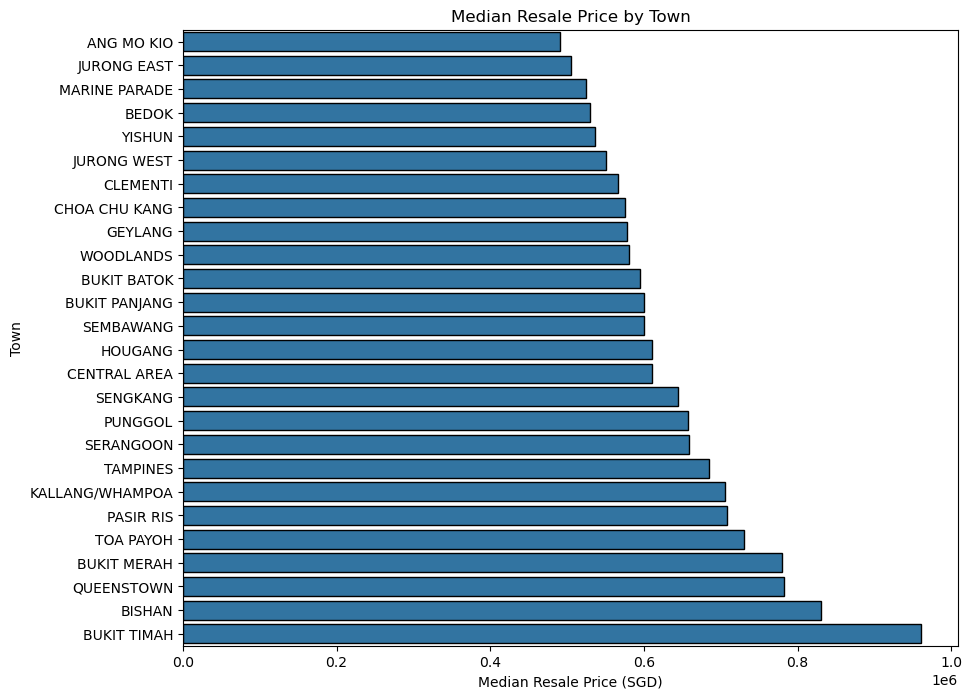

In [15]:
plt.figure(figsize=(10,8))
town_order = df.groupby('town')['resale_price'].median().sort_values()
sns.barplot(x=town_order.values, y=town_order.index,edgecolor='black')
plt.title('Median Resale Price by Town')
plt.xlabel('Median Resale Price (SGD)')
plt.ylabel('Town')
plt.show()

Location has a large effect on prices of flat.The most expensive town (such as the central and mature estates) have median prices above $950k, while the cheapest towns sit closer to $500k,a gap of roughly $450k.For the business of resaling flats, this confirms that location is one of the strongest price factor deciding the price of the flat, and a buyer or seller cannot judge fair value without accounting for town location. For modelling, this justifies keeping town as a feature, even though it has 26 categories and will expand the dataset.

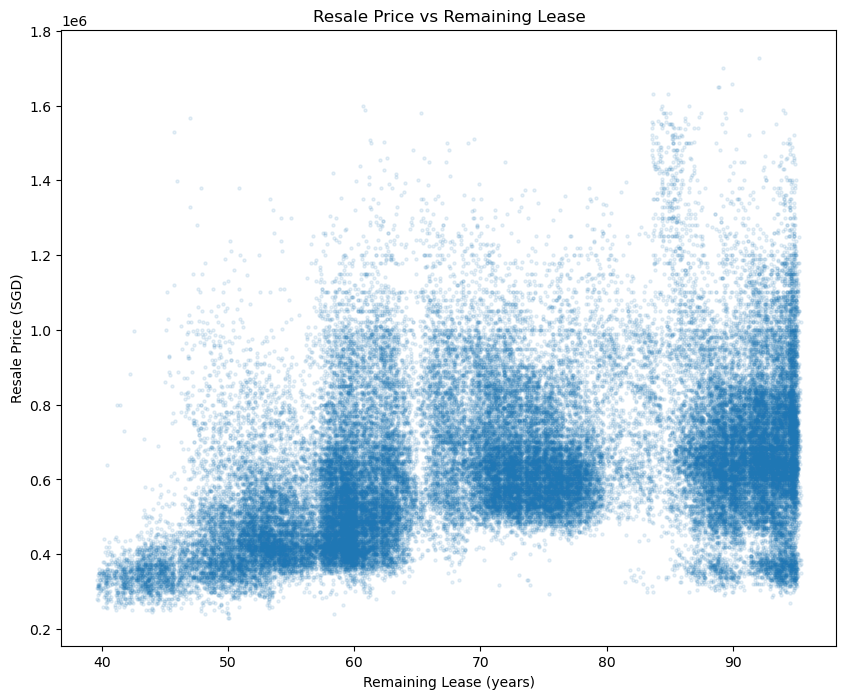

In [16]:
plt.figure(figsize=(10,8))
plt.scatter(df['remaining_lease_years'], df['resale_price'],alpha=0.1, s=5)
plt.title('Resale Price vs Remaining Lease')
plt.xlabel('Remaining Lease (years)')
plt.ylabel('Resale Price (SGD)')
plt.show()

There is a upward trent for the graph. flats with more years of lease remaining sell for higher prices.This shows"lease decay"—>an HDB flat is sold on a 99-year lease, and as the remaining lease shortens, the flat becomes less valuable because buyers have fewer years of use and face financing restrictions on older flats. The relationship between remaining lease and resale price is not tight, when looking at the lease length, there is still a wide spread of prices, showing that lease determine alongside location, size, and storey rather than on its own. For the business of resaling flats, this is an important and often overlooked factor,two similar flats can differ significantly in price purely because of remaining lease. For modelling, remaining_lease_years is a valuable numeric data.

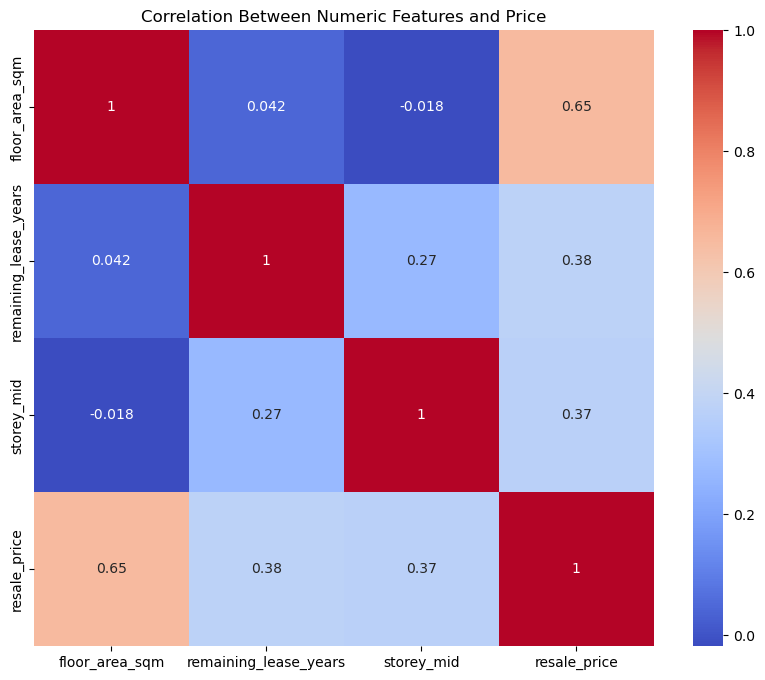

In [17]:
plt.figure(figsize=(10,8))
num_cols = ['floor_area_sqm','remaining_lease_years', 'storey_mid', 'resale_price']
sns.heatmap(df[num_cols].corr(), annot=True,cmap='coolwarm')
plt.title('Correlation Between Numeric Features and Price')
plt.show()


The heatmap shows how strongly each numeric feature correlates with resale price.floor area has the strongest correlation at(0.65), while remaining lease(0.38) and storey midpoint(0.37)contributing similarly to each other but are weaker than floor area. All three are positive and shows a similar trend:larger, higher, and longer-lease flats cost more.Looking at how the features relate to each other, the correlations between them are all low(the highest is 0.27 between storey and remaining lease), so none of the features are redundant and each adds its own information to the model. However, floor area and remaining lease have a correlation of just 0.042, which is sort of independent,meaning a flat's size and its lease affect the price of the flat independently.For business,from the earlier charts proved that size matters most, but lease and storey still add useful information. For modelling, this supports keeping all three numeric features, with no concern that the 3 factor are too dependent to each other.

## 5. Feature Engineering

I select the features most relevant to predicting price of flats. I kept 3 numeric features(floor_area_sqm, remaining_lease_years, storey_mid) and three category features(town, flat_type,flat_model).I dropped some columns that might cause error to the model:month is considered a date which could cause problem as it is a time factpr, blk and street_name are thousands of unique values that could cause the model to memorise specific addresses instead of learning general patterns, the original text versions of storey and lease,already replaced by numeric versions, and lease_commence_date because it is redundant, and it is also the inverse of remaining lease.

In [18]:
features = ['floor_area_sqm','remaining_lease_years','storey_mid','town', 'flat_type','flat_model']
X = df[features]
y = df['resale_price']

print("X shape:",X.shape)
print("y shape:", y.shape)

X shape: (66062, 6)
y shape: (66062,)


The three categorical features(town, flat_type,flat_model)are text base and must be convert to numbers.I use one-hot encoding, which creates a separate 0/1 column for each category. The reason why i choose one-hot encoding rather than assigning each category a number because these categories have no meaningful numeric order. For example "Bedok" is not greater than"Tampines",if i givi them numbers to cagetorise them, taht could mislead the model into assuming an order that does not exist causing an error.

In [ ]:
X = pd.get_dummies(X, columns=['town','flat_type','flat_model'],drop_first=True)
print("X shape after encoding:",X.shape)
X.head()

X shape after encoding: (66062, 54)


,floor_area_sqm,remaining_lease_years,storey_mid,town_BEDOK,town_BISHAN,town_BUKIT BATOK,town_BUKIT MERAH,town_BUKIT PANJANG,town_BUKIT TIMAH,town_CENTRAL AREA,...,flat_model_Multi Generation,flat_model_New Generation,flat_model_Premium Apartment,flat_model_Premium Apartment Loft,flat_model_Premium Maisonette,flat_model_Simplified,flat_model_Standard,flat_model_Terrace,flat_model_Type S1,flat_model_Type S2
169150,44.0,53.50,8.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
169151,44.0,55.58,5.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
169152,67.0,54.08,2.0,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
169153,68.0,55.17,5.0,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
169154,67.0,51.33,5.0,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [ ]:
print(df[['town','flat_type', 'flat_model']].head())

              town flat_type      flat_model
169150  ANG MO KIO    2 ROOM        Improved
169151  ANG MO KIO    2 ROOM        Improved
169152  ANG MO KIO    3 ROOM  New Generation
169153  ANG MO KIO    3 ROOM  New Generation
169154  ANG MO KIO    3 ROOM  New Generation


I split the data into training and test sets 80:20.The model learns only from the training set, and the test set is kept completely unseen until the final evaluation.This simulates how the model would perform on new, real flats it has never encountered, and prevents me from getting a missleading score when testing on data the model already memorised. I set random_state for consistency so the split train-test data stays consistent everytime i rerun the notebook.

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test =train_test_split(
    X, y, test_size=0.2,random_state=42)

print("Training set:",X_train.shape)
print("Test set:", X_test.shape)

Training set: (52849, 54)
Test set: (13213, 54)


## 6. Baseline Model

Before training my model,i established a baseline to predict the mean of training price for every flat, without considering the factors. This baseline model represents the simplest model where the model would guess with no information and considering of factor at all.

In [35]:
import numpy as np

y_pred_baseline = y_train.mean()

E = y_pred_baseline - y_test

AE = np.abs(E)
MAE = np.mean(AE)

SE = E**2
MSE = np.mean(SE)
RMSE = np.sqrt(MSE)

print(f"Baseline prediction (mean training price): ${y_pred_baseline:,.2f}")
print(f"Baseline MAE:  ${MAE:,.2f}")
print(f"Baseline MSE:  {MSE}")
print(f"Baseline RMSE: ${RMSE:,.2f}")

mase_baseline=MAE
rmse_baseline=RMSE

Baseline prediction (mean training price): $636,530.64
Baseline MAE:  $154,136.45
Baseline MSE:  40087313335.44392
Baseline RMSE: $200,218.16


## 7. Model Training & Comparison


I trained 3 different algorithms to compare their performance: Linear Regression (a simple linear model), Decision Tree (a non-linear model that splits on feature values), and Random Forest (an ensemble of many trees). Training more than one lets me compare a simple, interpretable model against more complex ones and choose based on evidence rather than assumption. All three are evaluated on the same unseen test set, using the same metrics as the baseline so the comparison is fair.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


def evaluate(model_name, y_pred):
    E = y_pred - y_test
    AE = np.abs(E)
    MAE = np.mean(AE)
    SE = E**2
    MSE = np.mean(SE)
    RMSE = np.sqrt(MSE)
    print(f"{model_name}")
    print(f"  MAE:  ${MAE:,.2f}")
    print(f"  RMSE: ${RMSE:,.2f}")
    return MAE, RMSE

In [27]:
linr = LinearRegression(fit_intercept=True)
linr.fit(X_train, y_train)
y_pred_linr = linr.predict(X_test)

mae_linr, rmse_linr = evaluate("Linear Regression", y_pred_linr)

Linear Regression
  MAE:  $55,172.81
  RMSE: $73,355.08


In [28]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

mae_dt, rmse_dt = evaluate("Decision Tree", y_pred_dt)

Decision Tree
  MAE:  $39,879.55
  RMSE: $60,019.28


In [29]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf, rmse_rf = evaluate("Random Forest", y_pred_rf)

Random Forest
  MAE:  $32,586.74
  RMSE: $47,376.87


In [ ]:
comparison = pd.DataFrame(
    {
        "Model": [
            "Baseline (mean price)",
            "Linear Regression",
            "Decision Tree",
            "Random Forest",
        ],
        "MAE": [mae_baseline, mae_linr, mae_dt, mae_rf],
        "RMSE": [rmse_baseline, rmse_linr, rmse_dt, rmse_rf],
    }
)
print(comparison)

                   Model            MAE           RMSE
0  Baseline (mean price)  154136.449549  200218.164349
1      Linear Regression   55172.811957   73355.080871
2          Decision Tree   39879.552895   60019.279777
3          Random Forest   32586.739357   47376.872981


all 3 models i tested beat the baseline,showing that flat attributes really predict price rather than the models memorising the average.Linear regression reduced RMSE by around 63%, decision tree by 70%, and random forest around 76%.
i selected random forest because itt performs best on both MAE and RMSE but it is off by about $32600 on typical flat. Since the median price is $611000, which is around 5% off, while the baseline was around 25% off. For a buyer or seller, being within 5% is close enough to be useful when agreeing on a price to deal.
Linear regression is the easiest model to explain,but it assume price go up in a straight line for every feature.My EDA showed this is not true,the price gap between towns is large and lease decay does not affect price.Decision Tree can pick up these patterns,but one tree tends to memorise the training data, so it does not do as well on new flats.random forest builds many trees and averages them out, so it keeps it flexibe but is less likely to overfit.whicj is why it has the lowest error.
One thing I noticed is that RMSE is higher than MAE for every model. This is because of the expensive flats in the long tail in the price histogram, a few very expensive flats creates large errors which RMSE penalize more.
Random frest is also practical to deploy.it only took about 13.4 sec to train and can be saved to a file for my Streamlit app to load.

## 8. Hyperparameter Tuning (RandomizedSearchCV)

random forest performed best out of the 3 model,so i tuned its hyoerparameters to see whether the default settings can be improved(these settings are called hyperparameters).I tested 3 hyperparameters:n_estimators(how many trees the forest build),max_depth(how deep each tree can grow),and min_samples_leaf(minimum flats required before the tree stops splitting the group).The project specification says to use RandomizedSearchCS with no more than 3 values for each setting, so i it 3 values per hyperparameter.I used cv=5, which means each combination is tested on 5 different splits of the training data instead of just 1, so the result is not just lucky. I also set random_state so i can get the same result everytime i run the notebook.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 2, 4],
}

rs_rf = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist_rf,
    cv=5,
    scoring="neg_mean_squared_error",
    n_iter=10,
    n_jobs=-1,
    random_state=42,
)

rs_rf.fit(X_train, y_train)

print("Best parameters:", rs_rf.best_params_)

Best parameters: {'n_estimators': 50, 'min_samples_leaf': 2, 'max_depth': None}


In [ ]:
best_rf = rs_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

mae_tuned, rmse_tuned = evaluate("Random Forest(tuned)", y_pred_best_rf)

Random Forest (tuned)
  MAE:  $32,211.56
  RMSE: $47,092.98


In [ ]:
final_comparison = pd.DataFrame(
    {
        "Model": [
            "Baseline (mean price)",
            "Linear Regression",
            "Decision Tree",
            "Random Forest (default)",
            "Random Forest (tuned)",
        ],
        "MAE": [mae_baseline, mae_linr, mae_dt, mae_rf, mae_tuned],
        "RMSE": [rmse_baseline, rmse_linr, rmse_dt, rmse_rf, rmse_tuned],
    }
)
print(final_comparison)

                     Model            MAE           RMSE
0    Baseline (mean price)  154136.449549  200218.164349
1        Linear Regression   55172.811957   73355.080871
2            Decision Tree   39879.552895   60019.279777
3  Random Forest (default)   32586.739357   47376.872981
4    Random Forest (tuned)   32211.555270   47092.979126


Tuning only helped a little.MAE went from $32587 down to $32212, which is about $375 better. RMSE went from $47377 down to $47093,which is about $284 better.This is only around 1% improvement.
this is because random forest already work well with its default settings, so there was not much room to improve.
The most interesting part is which settings the search chose.Out of the 3 options i gave for each setting,it picked n_estimators = 50, which is only half of the default 100 trees, but it still scored slightly better. This is useful for my web app because fewer trees means a smaller model file and faster predictions.It also picked max_depth = None, which means the trees work best when they can grow as deep as they needed.This matches what i saw in my EDA, because price depends on a mix of town, size,storey and lease instead of one simple rule. Lastly it picked min_samples_leaf = 2, so each group needs at least 2 flats instead of 1, which helps the model not memorise single flats.
I will use tis tuned random forest as my final model. Compared to the baseline of just guessing the average price,RMSE dropped from $200218 to $47093, which is 76% better. It predicts a typical flat at about $32200, which is around 5% of the median price of $611000.

## 9. Final Evaluation & Metric Justification

## 10. Conclusion & Model Export